<a href="https://colab.research.google.com/github/Paulelo/Capstone_project/blob/almond/group_28_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Submission Summary

| Item | Information |
|---|---|
| Group number | 28 |
| Your full name | NULL |
| Dataset | Stroke Prediction |
| Depth track | To be determined |
| Team members | To be added |
| Final model | To be determined |
| Stratified dummy F1 / ROC AUC | To be determined |
| Final model F1 / ROC AUC | To be determined |
| Leakage columns dropped | To be determined |
| Full run time on Colab | To be determined |

In [1]:
!pip install -q kagglehub


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub

C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

In [4]:
print(path)

C:\Users\USER\.cache\kagglehub\datasets\fedesoriano\stroke-prediction-dataset\versions\1


In [5]:
import os
os.listdir(path)

['healthcare-dataset-stroke-data.csv']

In [6]:
import pandas as pd

In [7]:
file_path = os.path.join(path, "healthcare-dataset-stroke-data.csv")
df = pd.read_csv(file_path)

In [8]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [9]:
df.shape

(5110, 12)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


In [11]:
missing_bmi = df["bmi"].isnull().sum()
missing_bmi_percentage = (missing_bmi / len(df)) * 100

print("Missing BMI:", missing_bmi)
print("Percentage missing:", missing_bmi_percentage)

Missing BMI: 201
Percentage missing: 3.9334637964774952


In [12]:
df.groupby(df["bmi"].isnull())["stroke"].mean()

bmi
False    0.042575
True     0.199005
Name: stroke, dtype: float64

In [13]:
df.groupby(df["bmi"].isnull())["age"].mean()

bmi
False    42.865374
True     52.049154
Name: age, dtype: float64

In [14]:
df["bmi"].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [15]:
median_bmi = df["bmi"].median()
df["bmi"] = df["bmi"].fillna(median_bmi)

In [16]:
df["bmi"].isnull().sum()

np.int64(0)

In [17]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [18]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [19]:
df["stroke"].value_counts(normalize=True) * 100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

In [20]:
df["age"].describe()

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

### Age Distribution:

The dataset contains individuals across a broad range of ages, from infants to 82 years old. The average age is approximately 43 years, while the median age is 45 years.

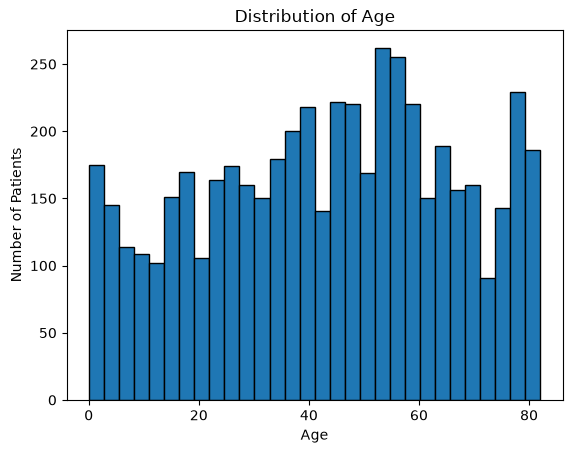

In [21]:
import matplotlib.pyplot as plt

plt.hist(df["age"], bins=30, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Distribution of Age")
plt.show()

In [22]:
df["avg_glucose_level"].describe()

count    5110.000000
mean      106.147677
std        45.283560
min        55.120000
25%        77.245000
50%        91.885000
75%       114.090000
max       271.740000
Name: avg_glucose_level, dtype: float64

### Average Glucose Level Distribution:

The distribution is right-skewed. Most patients have lower to moderate glucose levels, while a smaller number have much higher values, which pulls the mean above the median.

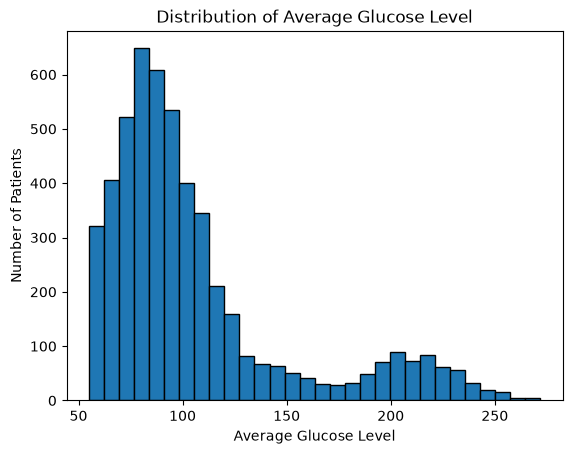

In [23]:
plt.hist(df["avg_glucose_level"], bins=30, edgecolor="black")
plt.xlabel("Average Glucose Level")
plt.ylabel("Number of Patients")
plt.title("Distribution of Average Glucose Level")
plt.show()

In [24]:
df["bmi"].describe()

count    5110.000000
mean       28.862035
std         7.699562
min        10.300000
25%        23.800000
50%        28.100000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64

### BMI Distribution:

BMI is slightly right-skewed, with most observations concentrated around the mid-20s to low-30s. A few unusually high BMI values are present, including a maximum of 97.6. These values were retained because a high value alone is not sufficient evidence that the observation is incorrect.

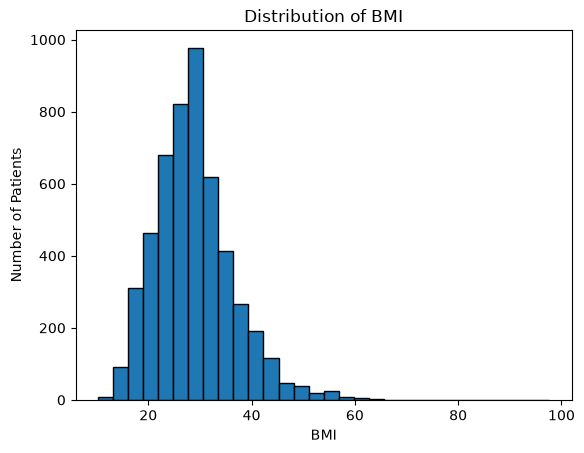

In [25]:
plt.hist(df["bmi"], bins=30, edgecolor="black")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.title("Distribution of BMI")
plt.show()

In [26]:
df["smoking_status"].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [27]:
df["smoking_status"].value_counts(normalize=True) * 100

smoking_status
never smoked       37.025440
Unknown            30.215264
formerly smoked    17.318982
smokes             15.440313
Name: proportion, dtype: float64

### Smoking Status Distribution:

The largest group consists of individuals who never smoked (37.0%), followed by individuals with unknown smoking status (30.2%). Former smokers account for 17.3%, while current smokers account for 15.4%. The relatively large Unknown category should be retained as a separate category because it represents unavailable information rather than confirmed non-smoking.

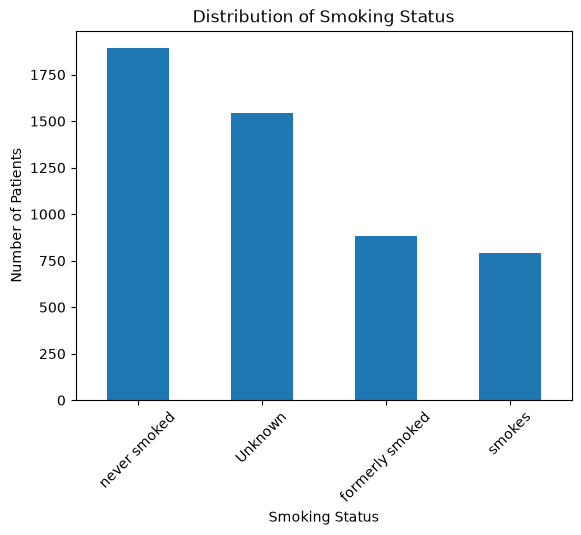

In [28]:
df["smoking_status"].value_counts().plot(kind="bar")

plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")
plt.title("Distribution of Smoking Status")
plt.xticks(rotation=45)
plt.show()

In [29]:
df["hypertension"].value_counts()

hypertension
0    4612
1     498
Name: count, dtype: int64

### Hypertension Distribution:

Most individuals in the dataset do not have hypertension (90.3%), while approximately 9.7% have hypertension. Although the column is stored as an integer, it represents a binary categorical variable where 0 means no hypertension and 1 means hypertension.

In [30]:
df["hypertension"].value_counts(normalize=True) * 100

hypertension
0    90.254403
1     9.745597
Name: proportion, dtype: float64

### Duplicate Check:

No exact duplicate rows were found in the dataset, so no rows were removed for duplication.

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.862035,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.699562,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [33]:
df.shape

(5110, 12)

In [34]:
df = df.drop(columns=['id'])

### Part 2 Feature Engineering and Encoding

#### Feature: Age Group
As age increases the  likelihood of having a stroke generally increases. As people get older, changes can occur in the blood vessels and the body becomes more susceptible to condition like hypertention. Grouping the ages makes it easier to see the pattern more clearly than raw numeric age.

In [35]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 35, 60, 100],
    labels=['Child', 'Young adult', 'Middle-aged', 'Senior']
)

#### Feature: Cardiovascular Condition Score
This feature combines hypertension and heart disease into one variable. Both conditions are associated with an increased risk of stroke, so combining them makes it easier to see whether a person has one or both of these known risk factors. it also givees the clustering alogrithm a simple way to capture the combined presence of these conditions.

In [36]:
df['cardiovascular_condition_score'] = ((df['hypertension'] == 1) | (df['heart_disease'] == 1)).astype(int)

#### Feature: Glucose to BMI Ratio
This feature is created by dividing the average glucose level by BMI. Glucose level and BMI provide different information about an individual's health and combining them allows us to explore whether their relationship reveals patterns that may not be as obvious whe  looking at each varaible separately. A higher ratio means that the person's glucose level os relatively high compared with their BMI. 

In [37]:
df['glucose_bmi_ratio'] = df['avg_glucose_level'] / df['bmi']

In [38]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,cardiovascular_condition_score,glucose_bmi_ratio
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Senior,1,6.248361
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,Senior,0,7.196085
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Senior,1,3.259077
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Middle-aged,0,4.977616
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Senior,1,7.255000


### Encoding: Categorical Variables
Since the categorical variables are norminal and have no natural order, one-hot encoding is used instead of label encoding, because label encoding could incorrectly imply a ranking between the categories. One-hot encoding creates a separate binary column for each category, allowing the model to treat them as distinct groups without assuming any order. drop_first=True is used for these variables because one category can be inferred from the remaining categories. Removing this category reduces redundant columns while retaining the information needed to represent the original varaible.

In [39]:
df = pd.get_dummies(
    df,
    columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'],
    drop_first=True
)

#### Encoding: Age Group
Unlike gender, work_type, Residence_type, and smoking_status. which are nominal categories with no ranking, age group is encoded according to it's natural order, since the categories progress from younger to older age groups. This preserves the ordered relationship between the age categories rather than treating them as unrelated groups.

In [40]:
age_order = {'Child': 0, 'Young adult': 1, 'Middle-aged': 2, 'Senior': 3}
df['age_group'] = df['age_group'].map(age_order).astype(int)

### Feature Scaling
The numeric columns in this dataset are on very different scales. For example, age ranges from about 0 to 82, while avg_glucose_level ranges up to 270+. If left unscaled, K-Means may give more influence to variables with larger numerical values simply because of their sclae, rather than because they are more important. StandardScaler was chosen over MinMaxScaler because the dataset contains an extreme outlier in bmi (max value 97.6). MinMaxScaler would compress most normal values into a very narrow range to accommodate that one outlier, distorting the scale for everyone else. StandardScaler instead centers each feature around its mean and scales it according to its standard deviation. This puts all numeric features on the same comparable scale without letting a single outlier dominate the transformation. This is particularly important for K-Means because the alogrithm uses distances to determine which observations are most similar.

In [41]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'avg_glucose_level', 'bmi', 'glucose_bmi_ratio']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [42]:
df[numeric_cols].describe()

,age,avg_glucose_level,bmi,glucose_bmi_ratio
count,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03
mean,5.005781e-17,1.001156e-16,-4.449583e-17,3.059088e-17
std,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00
min,-1.908261e+00,-1.126958e+00,-2.411027e+00,-1.894008e+00
25%,-8.061152e-01,-6.383223e-01,-6.575089e-01,-7.159625e-01
50%,7.843218e-02,-3.149945e-01,-9.898092e-02,-2.494721e-01
75%,7.860701e-01,1.754080e-01,5.115031e-01,4.586847e-01
max,1.714845e+00,3.657145e+00,8.928390e+00,7.123709e+00


## Clustering Analysis

Stroke is excluded from clustering because it is our target variable. Since clustering is meant to discover natural groupings in the data without using the outcome we're trying to understand, all other engineered, encoded, and scaled features are included. This allows us to see whether natural groups in the data have diiferent stroke rates later on.

In [43]:
X_cluster = df.drop(columns=['stroke'])

In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

##### Plotting the elbow curve

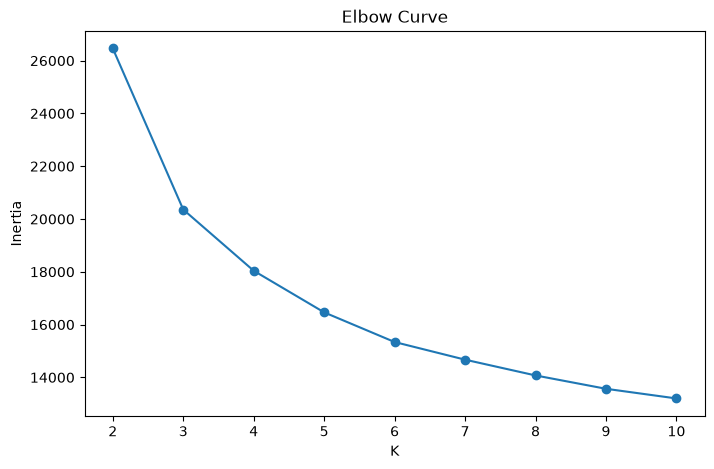

In [45]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

##### Plotting the silhouette score

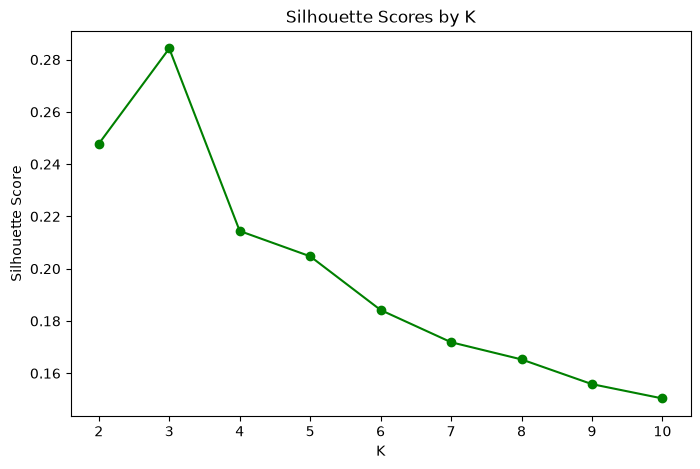

In [46]:
plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o', color='green')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores by K')
plt.show()

##### Choosing Final K: K3 was selected as the final number of clusters.
The elbow curve shows a sharp decrease in inertia from K=2 to K=3 (from 26000 to 20000). After K=4, the decrease in inertia becomes smaller and the curve flattens out, suggesting that adding more clusters provides less improvement and is just over-slicing. The silhouette score, which shows how well-separated clusters are from each other, also supports K=3, the score increases from 0.24 at K=2 to 0.28 at K=3, then declines steadily for every K after. Choosing a higher K only splits already well-formed groups into smaller, less meaningful pieces.

In [47]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_cluster)

df['cluster'].value_counts()

cluster
0    2831
2    1581
1     698
Name: count, dtype: int64

In [48]:
profile_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']

df.groupby('cluster')[profile_cols].mean()

,age,avg_glucose_level,bmi,hypertension,heart_disease,stroke
cluster,,,,,,
0,0.468777,-0.381872,0.292507,0.111621,0.057930,0.054045
1,0.792913,2.166901,0.440808,0.250716,0.157593,0.134670
2,-1.189475,-0.272877,-0.718387,0.004428,0.001265,0.001265


In [49]:
import numpy as np

# Reverse the scaling to get real-world values back, just for interpretation
original_values = scaler.inverse_transform(df[numeric_cols])
df_original_scale = pd.DataFrame(original_values, columns=numeric_cols, index=df.index)
df_original_scale['cluster'] = df['cluster']

df_original_scale.groupby('cluster')[['age', 'avg_glucose_level', 'bmi']].mean()

,age,avg_glucose_level,bmi
cluster,,,
0,53.825857,88.856863,31.113988
1,61.154728,204.263052,32.255731
2,16.332068,93.792056,23.331309


##### Cluster Profiling

Cluster 0 — "Middle-Aged, Moderate Risk" (2,831 patients): Average age 53.8, average glucose 88.9 (within normal range), average BMI 31.1 (obese range). Hypertension and heart disease rates are moderate, and the stroke rate (5.4%) is close to the overall dataset average (~4.9%).

Cluster 1 — "Older Adults with Diabetic-Range Glucose" (698 patients): Average age 61.2, average glucose 204.3 within the clinically diabetic range (126+ mg/dL). This group has the highest rates of hypertension (25.1%) and heart disease (15.8%), and the highest stroke rate by far at 13.5%, nearly 3x the overall dataset average.

Cluster 2 — "Young Adults, Low Risk" (1,581 patients): Average age just 16.3, average BMI 23.3 (normal range). Hypertension, heart disease and stroke rates are all near zero (0.1% stroke rate), consistent with a young, low-risk population.


#### PCA Visualization

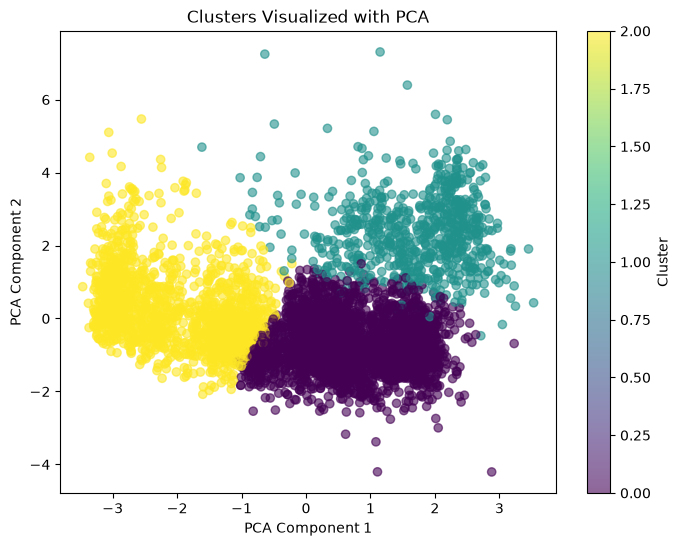

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clusters Visualized with PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()

##### PCA Visualization — Interpretation

The PCA plot shows three visually distinguishable clusters. Cluster 2 (yellow, young/low-risk) is clearly separated from the other two groups, consistent with its much lower average age (16.3) and near-zero rates of hypertension, heart disease, and stroke. Clusters 0 (purple) and 1 (teal) sit closer together with some overlap, which aligns with their more similar average ages (53.8 and 61.2), these two groups share more characteristics with each other than either does with Cluster 2, even though Cluster 1 stands out with much higher average glucose and stroke rate.